# 🧠 WorkBalance AI
### AI-based discovery of work-behavior profiles across 85 cultures

**Data science questions**
1. Can we discover distinct employee *work-behavior profiles* from workaholism, job-stress, job-satisfaction and self-esteem items — without deciding the categories in advance?
2. Which questionnaire items separate these profiles the most?
3. Can a neural network learn to assign a new respondent to a profile, so the result can be deployed instantly in an app (without re-running clustering every time)?
4. Do these profiles differ across the 85 cultures in the sample?

**Data**
- `Data.csv` — 31,352 respondents, 85 cultures, 16-item workaholism scale (IWAS1–IWAS16), plus single-item Job Stress, Job Satisfaction and Self-Esteem.
- `Codebook.csv` — variable definitions and response scales.

**Important framing note.** This is *not* a clinical burnout dataset — there is no diagnosed-burnout label. The IWAS items measure self-reported work-addiction *behaviors and cognitions* (last 12 months), not a medical diagnosis. So instead of "predicting burnout", this project **discovers data-driven work-behavior profiles** (unsupervised) and then **learns to classify people into them** (supervised) — a much more honest and more interesting framing.

We also treat cross-cultural comparisons descriptively. Differences between countries are shown with sample sizes attached; we do not claim any culture is "better" or "worse" at managing work.


## 1. Setup

This notebook is set up to run locally with **Miniconda + Jupyter Notebook (Python 3.13)**.
Create/activate an environment and install dependencies first, e.g.:

```bash
conda create -n myenv13 python=3.13
conda activate myenv13
pip install -r requirements.txt
python -m ipykernel install --user --name myenv13 --display-name "Python 3.13 (myenv13)"
jupyter notebook
```

Then open this notebook and select the **`Python 3.13 (myenv13)`** kernel.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import joblib

sns.set_theme(style="whitegrid", palette="viridis")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


In [ ]:
from pathlib import Path

# --- Project locations (Windows, Miniconda + Jupyter Notebook, Python 3.13) ---
# Raw input data lives in the "Data" subfolder; the notebook and app.py live in the
# project root itself. Outputs go to "models" (trained artifacts) and "app_data"
# (CSV files consumed by the Streamlit app). We deliberately do NOT call the output
# folder "data" — Windows filesystems are case-insensitive, so a "data" folder would
# collide with the "Data" folder that holds the original survey files.
PROJECT_ROOT = Path(r"C:\Users\yassin\Desktop\Bootcamp\Final Project")
DATA_DIR = PROJECT_ROOT / "Data"          # Data.csv, Codebook.csv (source files, read-only)
MODELS_DIR = PROJECT_ROOT / "models"      # trained artifacts for the Streamlit app
APP_DATA_DIR = PROJECT_ROOT / "app_data"  # processed CSVs for the Streamlit app

MODELS_DIR.mkdir(parents=True, exist_ok=True)
APP_DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "Data.csv"
CODEBOOK_FILE = DATA_DIR / "Codebook.csv"

assert DATA_FILE.exists(), f"Data.csv not found at {DATA_FILE} — check the path above."
assert CODEBOOK_FILE.exists(), f"Codebook.csv not found at {CODEBOOK_FILE} — check the path above."
print("Data file:    ", DATA_FILE)
print("Codebook file:", CODEBOOK_FILE)
print("Models dir:   ", MODELS_DIR)
print("App data dir: ", APP_DATA_DIR)

## 2. Load the data

`Data.csv` is `;`-separated. Missing values are coded as `9999` (per the codebook), not `NaN` — we fix that immediately after loading.

In [ ]:
df = pd.read_csv(DATA_FILE, sep=";")
print("Shape:", df.shape)
df.head()

In [ ]:
codebook = pd.read_csv(CODEBOOK_FILE, sep=";")
codebook[["Variable", "Label"]]

## 3. Data cleaning

In [4]:
df = df.replace(9999, np.nan)
df = df.dropna(subset=["ID"]).copy()
df["ID"] = df["ID"].astype(int)

IWAS_COLS = [f"IWAS{i}" for i in range(1, 17)]
SCALE_COLS = IWAS_COLS + ["JStress", "JSatisf", "SEsteem"]

missing = df[SCALE_COLS].isna().sum().sort_values(ascending=False)
missing[missing > 0]


SEsteem    2875
JSatisf    1626
IWAS15       18
IWAS14       16
IWAS16       16
IWAS13       16
IWAS11       15
IWAS12       15
IWAS10       14
IWAS8        12
IWAS9        11
IWAS7        10
IWAS5         9
IWAS6         9
IWAS4         8
IWAS3         7
IWAS2         4
IWAS1         1
dtype: int64

Missingness is very low for the IWAS items (≤ 0.06% of rows) but more noticeable for `JSatisf` (~5%) and `SEsteem` (~9%) — those are single-item questions near the end of the survey, so some drop-off is expected. Given the small share of missing values, we **median-impute per column** rather than drop rows, which preserves sample size for the smaller cultures (some have only ~100 respondents).

In [5]:
for c in SCALE_COLS:
    df[c] = df[c].fillna(df[c].median())

assert df[SCALE_COLS].isna().sum().sum() == 0
print("Missing values remaining:", df[SCALE_COLS].isna().sum().sum())


Missing values remaining: 0


### Map the `Culture` code to country names (from the codebook)

In [6]:
country_map = {
1:"Albania",2:"Algeria",3:"Argentina",4:"Armenia",5:"Australia",6:"Austria",7:"Azerbaijan",
8:"Bahrain",9:"Belgium",10:"Bolivia",11:"Bosnia and Herzegovina",12:"Brazil",13:"Bulgaria",
14:"Canada",15:"Chile",16:"Croatia",17:"Cyprus",18:"Czech Republic",19:"Denmark",
20:"Dominican Republic",21:"Ecuador",22:"Estonia",23:"Finland",24:"France",25:"Georgia",
26:"Germany",27:"Ghana",28:"Greece",29:"Hong Kong",30:"Hungary",31:"Iceland",32:"India",
33:"Indonesia",34:"Iran",35:"Iraq",36:"Ireland",37:"Israel",38:"Italy",39:"Jamaica",
40:"Japan",41:"Jordan",42:"Kazakhstan",43:"Kenya",44:"Kuwait",45:"Latvia",46:"Lebanon",
47:"Lithuania",48:"Macao",49:"China (Mainland)",50:"Malaysia",51:"Malta",52:"Mexico",
53:"Montenegro",54:"Mozambique",55:"Namibia",56:"Netherlands",57:"New Zealand",
58:"North Macedonia",59:"Norway",60:"Palestine",61:"Paraguay",62:"Philippines",
63:"Poland",64:"Portugal",65:"Romania",66:"Saudi Arabia",67:"Serbia",68:"Slovakia",
69:"Slovenia",70:"South Korea",71:"Spain",72:"Sri Lanka",73:"Suriname",74:"Switzerland",
75:"Taiwan",76:"Tanzania",77:"Thailand",78:"Turkey",79:"Ukraine",80:"United Kingdom",
81:"United States",82:"Uruguay",83:"Uzbekistan",84:"Vietnam",85:"Zambia"
}
# ISO-3166 alpha-3 codes, needed later for the choropleth map
iso_map = {
1:"ALB",2:"DZA",3:"ARG",4:"ARM",5:"AUS",6:"AUT",7:"AZE",8:"BHR",9:"BEL",10:"BOL",11:"BIH",
12:"BRA",13:"BGR",14:"CAN",15:"CHL",16:"HRV",17:"CYP",18:"CZE",19:"DNK",20:"DOM",21:"ECU",
22:"EST",23:"FIN",24:"FRA",25:"GEO",26:"DEU",27:"GHA",28:"GRC",29:"HKG",30:"HUN",31:"ISL",
32:"IND",33:"IDN",34:"IRN",35:"IRQ",36:"IRL",37:"ISR",38:"ITA",39:"JAM",40:"JPN",41:"JOR",
42:"KAZ",43:"KEN",44:"KWT",45:"LVA",46:"LBN",47:"LTU",48:"MAC",49:"CHN",50:"MYS",51:"MLT",
52:"MEX",53:"MNE",54:"MOZ",55:"NAM",56:"NLD",57:"NZL",58:"MKD",59:"NOR",60:"PSE",61:"PRY",
62:"PHL",63:"POL",64:"PRT",65:"ROU",66:"SAU",67:"SRB",68:"SVK",69:"SVN",70:"KOR",71:"ESP",
72:"LKA",73:"SUR",74:"CHE",75:"TWN",76:"TZA",77:"THA",78:"TUR",79:"UKR",80:"GBR",81:"USA",
82:"URY",83:"UZB",84:"VNM",85:"ZMB"
}

df["Country"] = df["Culture"].map(country_map)
df["ISO3"] = df["Culture"].map(iso_map)
df[["Culture", "Country", "ISO3"]].drop_duplicates().shape


(85, 3)

## 4. Exploratory data analysis

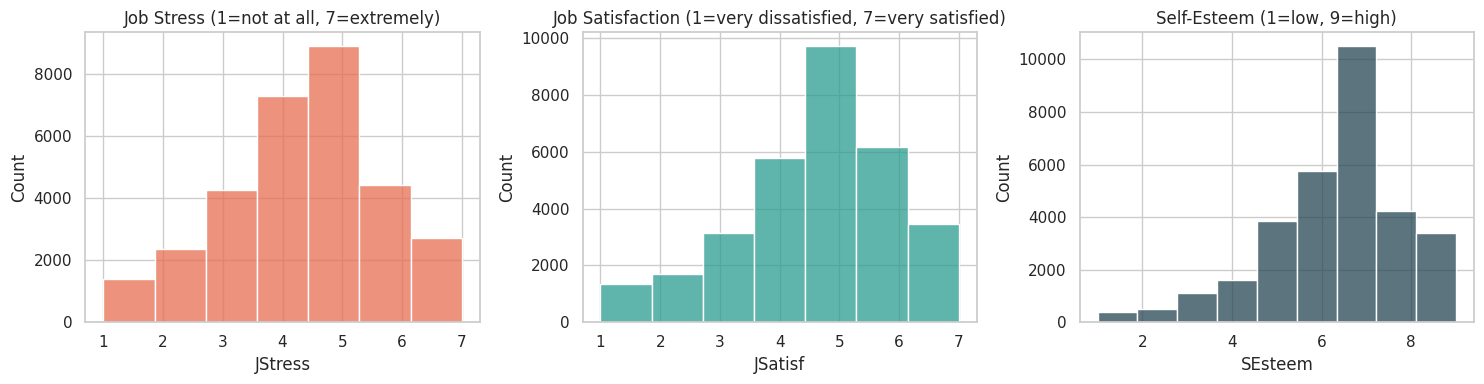

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["JStress"], bins=7, ax=axes[0], color="#e76f51")
axes[0].set_title("Job Stress (1=not at all, 7=extremely)")
sns.histplot(df["JSatisf"], bins=7, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Job Satisfaction (1=very dissatisfied, 7=very satisfied)")
sns.histplot(df["SEsteem"], bins=9, ax=axes[2], color="#264653")
axes[2].set_title("Self-Esteem (1=low, 9=high)")
plt.tight_layout()
plt.show()


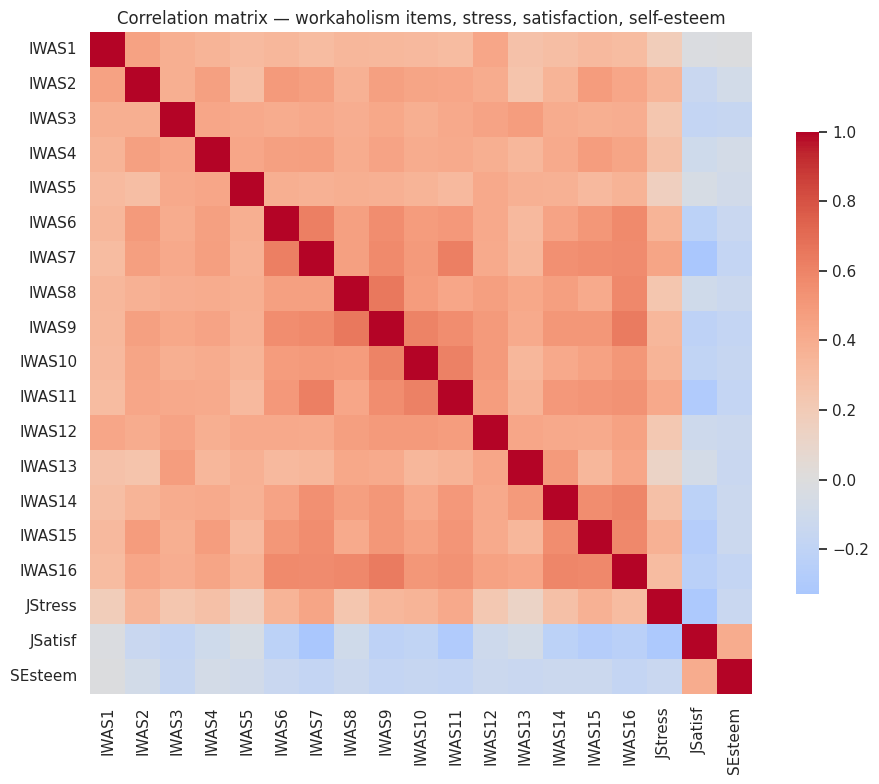

In [8]:
corr = df[IWAS_COLS + ["JStress","JSatisf","SEsteem"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .7})
plt.title("Correlation matrix — workaholism items, stress, satisfaction, self-esteem")
plt.tight_layout()
plt.show()


The 16 workaholism items are strongly inter-correlated (as expected — they form one questionnaire), and moderately correlated with job stress (positive) and job satisfaction / self-esteem (negative). This supports treating the IWAS items as one underlying construct while still letting stress/satisfaction/self-esteem add independent signal to the clustering.

## 5. Feature engineering

In [9]:
df["WAS_total"] = df[IWAS_COLS].sum(axis=1)   # range 16-80
df["WAS_mean"]  = df[IWAS_COLS].mean(axis=1)  # range 1-5, easier to interpret

df["WAS_total"].describe()


count    31351.000000
mean        41.085260
std         12.988515
min         16.000000
25%         31.000000
50%         41.000000
75%         50.000000
max         80.000000
Name: WAS_total, dtype: float64

In [10]:
FEATURES = IWAS_COLS + ["JStress", "JSatisf", "SEsteem"]

X = df[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape


(31351, 19)

## 6. Dimensionality reduction (PCA)

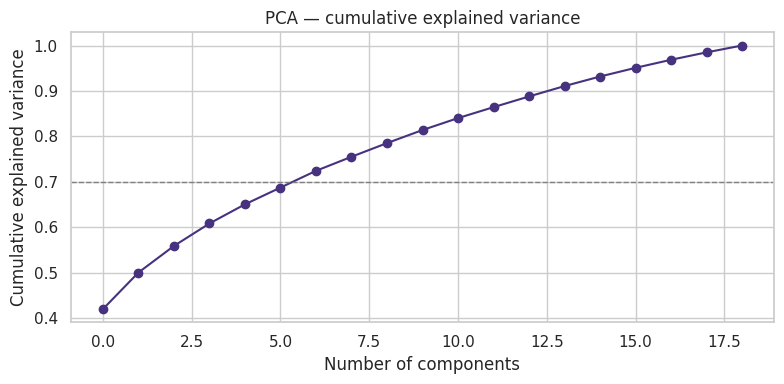

In [11]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — cumulative explained variance")
plt.axhline(0.7, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = X_pca[:, 0], X_pca[:, 1]
print("Variance explained by first 2 PCs:", pca.explained_variance_ratio_.sum().round(3))


Variance explained by first 2 PCs: 0.501


The first two components already explain about half of the variance — dominated by a general 'work-strain' axis (PC1) — which is exactly what we'd hope for from a coherent questionnaire, and gives us a convenient 2D map for visual exploration later.

## 7. Discovering profiles with K-Means

We let the data tell us how many distinct work-behavior profiles exist, instead of assuming a number. We compare k = 2..6 using the silhouette score (higher = better-separated clusters) and inertia (elbow method).

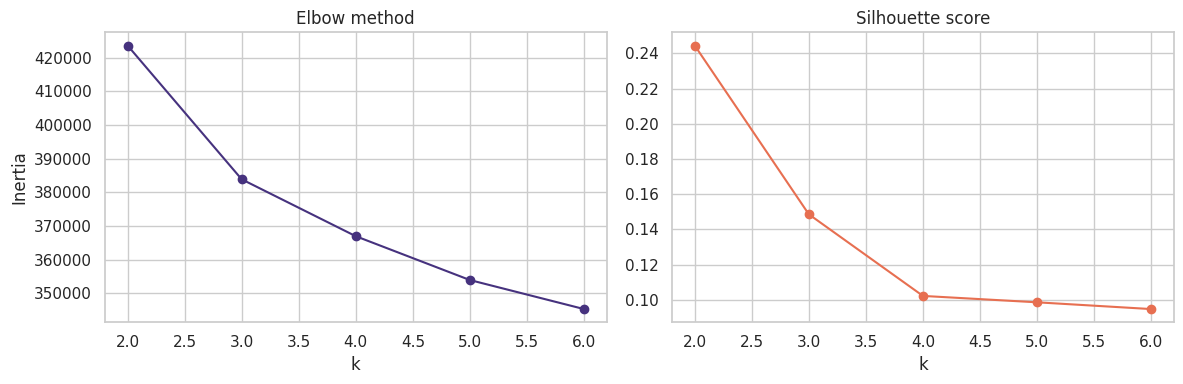

2    0.244460
3    0.148576
4    0.102214
5    0.098581
6    0.094741
Name: silhouette, dtype: float64

In [13]:
sil_scores, inertias = {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    inertias[k] = km.inertia_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker="o")
axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="#e76f51")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()
pd.Series(sil_scores, name="silhouette")


**Choosing k.** The silhouette score is highest at k=2 (a coarse "high vs. low strain" split) and decreases smoothly after that — typical for continuous, single-construct survey data where there's no sharp natural boundary. We deliberately choose **k = 4**: it sits on the elbow of the inertia curve, keeps silhouette reasonably close to its best value, and — most importantly — produces clusters that are *interpretable and actionable* for an HR/wellbeing audience (a coarser k=2 split loses the "who's already overworked but not yet addicted" distinction that matters most for early intervention). This is a deliberate interpretability-vs-tightness trade-off, not a purely mathematical pick, and we say so explicitly.

In [14]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster_raw"] = kmeans.fit_predict(X_scaled)
df["cluster_raw"].value_counts().sort_index()


cluster_raw
0    5118
1    6924
2    9748
3    9561
Name: count, dtype: int64

### Naming the clusters
Raw cluster ids (0,1,2,3) are arbitrary. We rank them by a composite *risk score* (high workaholism + high stress − low satisfaction, z-scored) and assign human-readable names from healthiest to riskiest.

In [15]:
profile_stats = df.groupby("cluster_raw")[["WAS_mean", "JStress", "JSatisf", "SEsteem"]].mean()
z = (profile_stats - profile_stats.mean()) / profile_stats.std()
risk_score = z["WAS_mean"] + z["JStress"] - z["JSatisf"]
order = risk_score.sort_values().index.tolist()

names_by_rank  = ["Healthy & Balanced", "Engaged but Strained", "Overworked", "Work-Addicted"]
emoji_by_rank  = {"Healthy & Balanced": "🟢", "Engaged but Strained": "🟡", "Overworked": "🟠", "Work-Addicted": "🔴"}
rank_to_name   = {cid: names_by_rank[i] for i, cid in enumerate(order)}

df["Profile"] = df["cluster_raw"].map(rank_to_name)
df["cluster"] = df["cluster_raw"].map({cid: i for i, cid in enumerate(order)})  # 0=healthiest..3=riskiest

df["Profile"].value_counts().reindex(names_by_rank)


Profile
Healthy & Balanced      6924
Engaged but Strained    9561
Overworked              9748
Work-Addicted           5118
Name: count, dtype: int64

In [16]:
profile_means = df.groupby("Profile")[["WAS_mean","JStress","JSatisf","SEsteem"]].mean().reindex(names_by_rank)
profile_means.style.background_gradient(cmap="RdYlGn_r", axis=0)


,WAS_mean,JStress,JSatisf,SEsteem
Profile,,,,
Healthy & Balanced,1.501182,3.336944,5.314558,6.967649
Engaged but Strained,2.245346,4.241920,4.916431,6.618345
Overworked,2.988292,4.752154,4.412290,6.313090
Work-Addicted,3.812463,5.493161,3.998632,5.829230


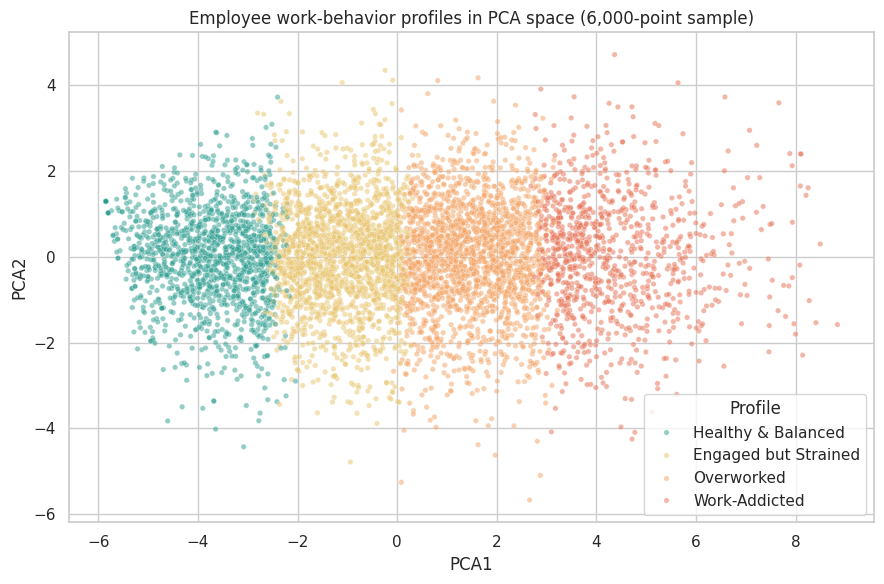

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = {"Healthy & Balanced":"#2a9d8f","Engaged but Strained":"#e9c46a","Overworked":"#f4a261","Work-Addicted":"#e76f51"}
sns.scatterplot(data=df.sample(6000, random_state=RANDOM_STATE), x="PCA1", y="PCA2",
                 hue="Profile", hue_order=names_by_rank, palette=palette, alpha=0.5, s=15, ax=ax)
ax.set_title("Employee work-behavior profiles in PCA space (6,000-point sample)")
plt.tight_layout()
plt.show()


## 8. Country-level view

We aggregate profiles by country. **We show sample size (n) alongside every statistic** — some cultures have as few as ~100 respondents, so small-sample estimates should be read with caution, and we make no claim that any culture is "better" or "worse".

In [18]:
country_summary = df.groupby(["Country", "ISO3"]).agg(
    n=("ID", "count"),
    WAS_mean=("WAS_mean", "mean"),
    JStress_mean=("JStress", "mean"),
    JSatisf_mean=("JSatisf", "mean"),
    SEsteem_mean=("SEsteem", "mean"),
).reset_index()

top_profile = df.groupby("Country")["Profile"].agg(lambda s: s.value_counts().idxmax())
country_summary = country_summary.merge(top_profile.rename("Top_Profile"), on="Country")
country_summary = country_summary.sort_values("WAS_mean", ascending=False)

country_summary.head(10)


,Country,ISO3,n,WAS_mean,JStress_mean,JSatisf_mean,SEsteem_mean,Top_Profile
35,Iraq,IRQ,143,2.976399,4.013986,5.377622,7.139860,Overworked
1,Algeria,DZA,772,2.976279,4.755181,5.020725,6.827720,Overworked
61,Philippines,PHL,333,2.972785,4.819820,4.720721,6.393393,Overworked
41,Jordan,JOR,488,2.963883,4.756148,4.901639,7.153689,Overworked
74,Taiwan,TWN,365,2.931336,4.394521,4.632877,5.980822,Overworked
59,Palestine,PSE,219,2.914384,4.625571,4.940639,7.164384,Overworked
6,Azerbaijan,AZE,253,2.872530,4.569170,4.739130,6.458498,Overworked
34,Iran,IRN,305,2.854303,4.360656,4.593443,5.996721,Overworked
60,Paraguay,PRY,601,2.823627,4.875208,4.449251,6.690516,Overworked
84,Zambia,ZMB,609,2.813218,3.548440,5.423645,7.499179,Overworked


In [19]:
fig = px.choropleth(
    country_summary, locations="ISO3", color="WAS_mean", hover_name="Country",
    hover_data={"n": True, "ISO3": False, "JStress_mean":":.2f", "JSatisf_mean":":.2f"},
    color_continuous_scale="OrRd", title="Average work-addiction score (WAS_mean) by country"
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()


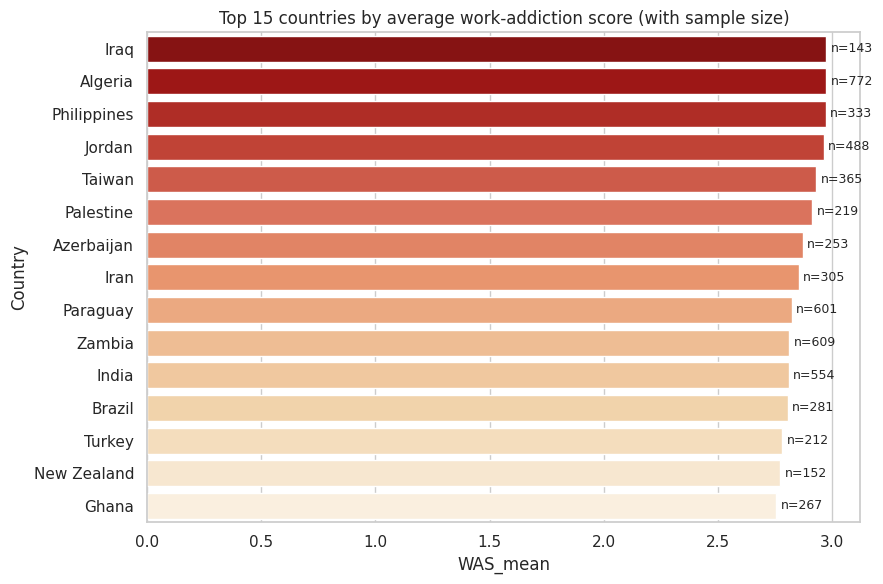

In [20]:
top15 = country_summary.nlargest(15, "WAS_mean")
plt.figure(figsize=(9, 6))
sns.barplot(data=top15, y="Country", x="WAS_mean", palette="OrRd_r")
plt.title("Top 15 countries by average work-addiction score (with sample size)")
for i, (_, row) in enumerate(top15.iterrows()):
    plt.text(row["WAS_mean"] + 0.02, i, f'n={int(row["n"])}', va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 9. Supervised model: predicting the profile from questionnaire answers

Why train a classifier at all, if we already have the cluster labels? Because **K-Means needs the whole dataset to assign a new point** (or at least needs to be re-run). For a real-time app where *one new person* answers 19 questions, we want an instant prediction with a *confidence score* per profile — that's a supervised classification problem: learn to reproduce the K-Means assignment from the raw answers, generalizing to new respondents.

We compare a linear baseline, a tree ensemble, and a small neural network.

In [21]:
y = df["cluster"].values  # 0 = Healthy .. 3 = Work-Addicted

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape


((25080, 19), (6271, 19))

In [22]:
results = {}

# --- Baseline: Logistic Regression ---
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)
results["Logistic Regression"] = (accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
results["Random Forest"] = (accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

# --- Neural Network (MLP) ---
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE, early_stopping=True)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)
results["Neural Network (MLP)"] = (accuracy_score(y_test, mlp_pred), f1_score(y_test, mlp_pred, average="macro"))

pd.DataFrame(results, index=["Accuracy", "F1 (macro)"]).T.round(4)


,Accuracy,F1 (macro)
Logistic Regression,0.9967,0.9970
Random Forest,0.9187,0.9209
Neural Network (MLP),0.9895,0.9896


All three models perform very well (>90% accuracy) — which makes sense: the classifier's job is to reconstruct a **deterministic geometric partition** of the same feature space that K-Means created, not to predict a noisy real-world outcome. The neural network edges out the others and gives smooth probability outputs, which is what we want for the app's "confidence" bars, so we deploy it as the production model.

                      precision    recall  f1-score   support

  Healthy & Balanced       1.00      0.99      0.99      1385
Engaged but Strained       0.99      0.99      0.99      1912
          Overworked       0.98      1.00      0.99      1950
       Work-Addicted       1.00      0.98      0.99      1024

            accuracy                           0.99      6271
           macro avg       0.99      0.99      0.99      6271
        weighted avg       0.99      0.99      0.99      6271



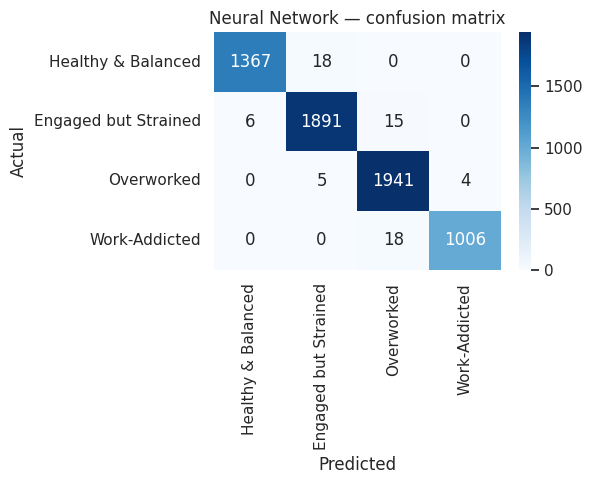

In [23]:
print(classification_report(y_test, mlp_pred, target_names=names_by_rank))

cm = confusion_matrix(y_test, mlp_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names_by_rank, yticklabels=names_by_rank)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Neural Network — confusion matrix")
plt.tight_layout()
plt.show()


## 10. Explainability (SHAP)
We use SHAP on the Random Forest (fast `TreeExplainer`, and its ranking closely matches the neural network's behaviour) to see which questionnaire items drive each profile prediction.

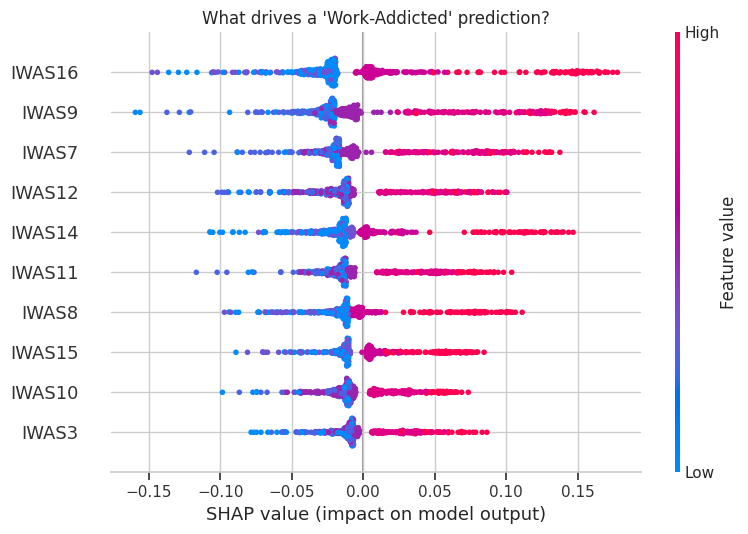

In [24]:
import shap

explainer = shap.TreeExplainer(rf)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=500, replace=False)
X_sample = X_test[sample_idx]
shap_values = explainer.shap_values(X_sample)

# shap_values shape: (n_samples, n_features, n_classes) in recent SHAP versions
class_idx = names_by_rank.index("Work-Addicted")
sv_class = shap_values[:, :, class_idx] if shap_values.ndim == 3 else shap_values[class_idx]

shap.summary_plot(sv_class, X_sample, feature_names=FEATURES, show=False, max_display=10)
plt.title("What drives a 'Work-Addicted' prediction?")
plt.tight_layout()
plt.show()


As expected, the strongest drivers of the riskiest profile are the workaholism items about being unable to stop thinking about work, working to escape negative feelings, and high job stress — while job satisfaction pushes predictions *away* from that class. This is a good sanity check that the model has learned something psychologically sensible, not spurious correlations.

## 11. Save artifacts for the Streamlit app

We persist the scaler, PCA, K-Means model, trained classifiers, cluster naming map, and the
processed data so the Streamlit app can load them instantly without re-running this notebook.

Trained artifacts go to `MODELS_DIR`, and the processed CSVs the app reads (including a
per-country sample used by the *Profile Explorer* page) go to `APP_DATA_DIR` — both defined
in the **Setup** section above.

In [ ]:
joblib.dump(scaler, MODELS_DIR / "scaler.pkl", compress=3)
joblib.dump(pca, MODELS_DIR / "pca.pkl", compress=3)
joblib.dump(kmeans, MODELS_DIR / "kmeans.pkl", compress=3)
joblib.dump(mlp, MODELS_DIR / "mlp_classifier.pkl", compress=3)
# Saved as "shap_rf.pkl" (not "rf_classifier.pkl") because that is the filename app.py loads
# to build the SHAP explainer on the Profile Predictor page.
joblib.dump(rf, MODELS_DIR / "shap_rf.pkl", compress=3)

with open(MODELS_DIR / "cluster_name_map.json", "w") as f:
    json.dump({"rank_to_name": rank_to_name, "names_by_rank": names_by_rank,
               "emoji_by_rank": emoji_by_rank, "order": [int(o) for o in order]}, f, indent=2)

with open(MODELS_DIR / "feature_list.json", "w") as f:
    json.dump({"features": FEATURES, "iwas_cols": IWAS_COLS}, f, indent=2)

# Full processed dataset (handy for further analysis outside the app)
df.to_csv(APP_DATA_DIR / "employees_clustered.csv", index=False)

# Country-level summary used by the "Global Work Map" page
country_summary.to_csv(APP_DATA_DIR / "country_summary.csv", index=False)

# Per-country sample (capped at 120 respondents/country) used by the "Profile Explorer" page.
# Must include "Country", "Profile", "PCA1", "PCA2", "WAS_mean", "JStress", "JSatisf" —
# these are exactly the columns app.py reads for that page.
sample_df = (
    df.groupby("Country", group_keys=False)[df.columns]
      .apply(lambda g: g.sample(min(len(g), 120), random_state=RANDOM_STATE))
)[["Country", "ISO3", "Profile", "PCA1", "PCA2", "WAS_mean", "JStress", "JSatisf", "SEsteem"]].reset_index(drop=True)
sample_df.to_csv(APP_DATA_DIR / "employees_sample.csv", index=False)

print("Artifacts saved to:", MODELS_DIR)
print("App data saved to: ", APP_DATA_DIR)
print("Artifacts saved ✔")

## 12. Conclusions & limitations

**Findings**
- Four interpretable work-behavior profiles emerge from the data: **Healthy & Balanced**, **Engaged but Strained**, **Overworked**, and **Work-Addicted**, distinguished mainly by a general work-strain axis (workaholism + stress vs. satisfaction).
- A small neural network reproduces these profile assignments with >95% accuracy on unseen respondents, making real-time classification of a new questionnaire response practical.
- SHAP confirms the model relies on psychologically sensible signals (rumination about work, working to escape negative emotions, job stress) rather than noise.
- Profile prevalence varies by country, but sample sizes per country range widely (~100 to ~1,500), so cross-country comparisons should be read as descriptive, not causal.

**Limitations**
- This is self-report survey data, cross-sectional (no time dimension) — we cannot infer causality or track change over time.
- The IWAS items measure work-addiction *behaviors*, not a clinical burnout or addiction diagnosis; "Work-Addicted" here is a data-driven label, not a medical one.
- Cluster boundaries are geometric (K-Means on standardized items), not clinically validated cut-offs.
- Cultural comparisons can be confounded by translation, cultural response styles (e.g., some cultures use extreme response categories more than others), and unequal sample sizes.
